# 无光伏参与收益分析

在与主实验相同的参数下，对比两种场景：

- 场景A：原始模型，允许光伏参与
- 场景B：禁用光伏参与，保留资源维度但将 PV 的功率与能量约束置零

重点观察：

- 总收益与收益分解
- 修正后的 `bid_p`（基础功率投标）
- 修正后的 `bid_r`（调频容量投标）


In [1]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

project_root = Path.cwd().resolve()
for candidate in [project_root, *project_root.parents]:
    if (candidate / "myexp").exists():
        project_root = candidate
        break
else:
    raise RuntimeError("未找到项目根目录，请从仓库内运行此 notebook。")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from myexp import notebook_viz_utils as viz_utils
import myexp.main as main_module

importlib.reload(viz_utils)
importlib.reload(main_module)

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")

project_root


WindowsPath('E:/研究活/Real-time-operation-strategy-of-virtual-power-plants-main')

In [2]:
DAY_PRICE = 15
FORCE_RERUN = False
cache_dir = project_root / "results" / "notebook_cache"

sim_with_pv = viz_utils.load_or_run_simulation(
    project_root=project_root,
    cache_path=cache_dir / f"sim_day{DAY_PRICE}_with_pv.pkl",
    force_rerun=FORCE_RERUN,
    data_source="data_process",
    save_results=False,
    day_price=DAY_PRICE,
)

sim_without_pv = viz_utils.load_or_run_simulation(
    project_root=project_root,
    cache_path=cache_dir / f"sim_day{DAY_PRICE}_without_pv.pkl",
    force_rerun=FORCE_RERUN,
    data_source="data_process",
    save_results=False,
    day_price=DAY_PRICE,
    disable_pv=True,
)

print(f"价格日: day {DAY_PRICE}")
print("两组场景仿真已准备完成。")


价格日: day 15
两组场景仿真已准备完成。


In [3]:
def build_profit_summary(sim: dict, label: str) -> dict:
    result = sim["result"]
    return {
        "场景": label,
        "日前利润(USD)": float(np.sum(result["Profit_day"])),
        "实际利润(USD)": float(np.sum(result["actualProfit"])),
        "实际能量收益(USD)": float(np.sum(result["actualEnergyRevenue"])),
        "实际容量收益(USD)": float(np.sum(result["actualRegCapacity"])),
        "实际里程收益(USD)": float(np.sum(result["actualRegMileage"])),
        "实际电池退化费用(USD)": float(np.sum(result["actualBatteryDeg"])),
        "修正 bid_p 均值(MW)": float(np.mean(result["Bid_P_rev"])),
        "修正 bid_r 均值(MW)": float(np.mean(result["Bid_R_rev"])),
    }

summary_df = pd.DataFrame([
    build_profit_summary(sim_with_pv, "含光伏参与"),
    build_profit_summary(sim_without_pv, "无光伏参与"),
])

baseline_profit = summary_df.loc[summary_df["场景"] == "含光伏参与", "实际利润(USD)"].iloc[0]
summary_df["相对含光伏利润变化(USD)"] = summary_df["实际利润(USD)"] - baseline_profit
summary_df["相对含光伏利润变化(%)"] = summary_df["相对含光伏利润变化(USD)"] / baseline_profit * 100.0

display(summary_df.round(3))


,场景,日前利润(USD),实际利润(USD),实际能量收益(USD),实际容量收益(USD),实际里程收益(USD),实际电池退化费用(USD),修正 bid_p 均值(MW),修正 bid_r 均值(MW),相对含光伏利润变化(USD),相对含光伏利润变化(%)
0,含光伏参与,2733.792,2958.137,385.545,1838.361,1662.47,928.239,0.154,1.435,0.000,0.000
1,无光伏参与,1165.811,1360.667,-439.145,1462.321,1265.73,928.239,-0.266,1.162,-1597.471,-54.003


C:\Users\admin\AppData\Local\Temp\ipykernel_6016\3646597060.py:26: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_6016\3646597060.py:26: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_6016\3646597060.py:26: UserWarning: Glyph 20462 (\N{CJK UNIFIED IDEOGRAPH-4FEE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_6016\3646597060.py:26: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_6016\3646597060.py:26: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_6016\3646597060.py:26: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missi

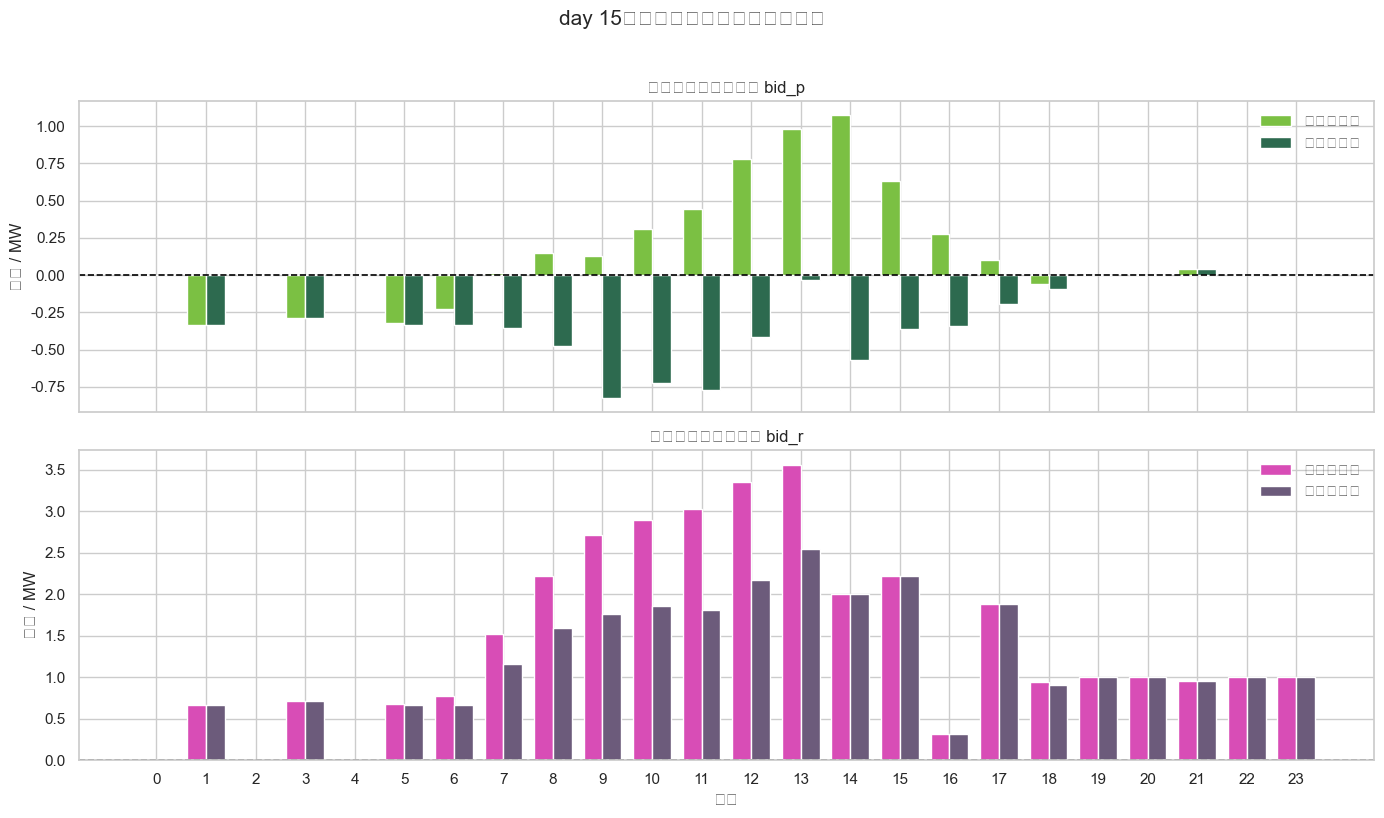

In [4]:
slot_with_pv = viz_utils.build_slot_df(sim_with_pv)
slot_without_pv = viz_utils.build_slot_df(sim_without_pv)

hours = slot_with_pv["hour"].to_numpy()
width = 0.38

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(hours - width / 2, slot_with_pv["bid_p_rev"], width=width, color="#7BC043", label="含光伏参与")
axes[0].bar(hours + width / 2, slot_without_pv["bid_p_rev"], width=width, color="#2D6A4F", label="无光伏参与")
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1.2)
axes[0].set_ylabel("功率 / MW")
axes[0].set_title("修正后基础功率投标 bid_p")
axes[0].legend(frameon=False)

axes[1].bar(hours - width / 2, slot_with_pv["bid_r_rev"], width=width, color="#D84DB6", label="含光伏参与")
axes[1].bar(hours + width / 2, slot_without_pv["bid_r_rev"], width=width, color="#6C5B7B", label="无光伏参与")
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("时段")
axes[1].set_ylabel("功率 / MW")
axes[1].set_title("修正后调频容量投标 bid_r")
axes[1].legend(frameon=False)
axes[1].set_xticks(hours)

fig.suptitle(f"day {DAY_PRICE}：有无光伏参与时的投标对比", y=1.02, fontsize=15)
fig.tight_layout()
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_6016\3894611356.py:21: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_6016\3894611356.py:21: UserWarning: Glyph 38469 (\N{CJK UNIFIED IDEOGRAPH-9645}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_6016\3894611356.py:21: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_6016\3894611356.py:21: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_6016\3894611356.py:21: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_6016\3894611356.py:21: UserWarning: Glyph 30410 (\N{CJK UNIFIED IDEOGRAPH-76CA}) missi

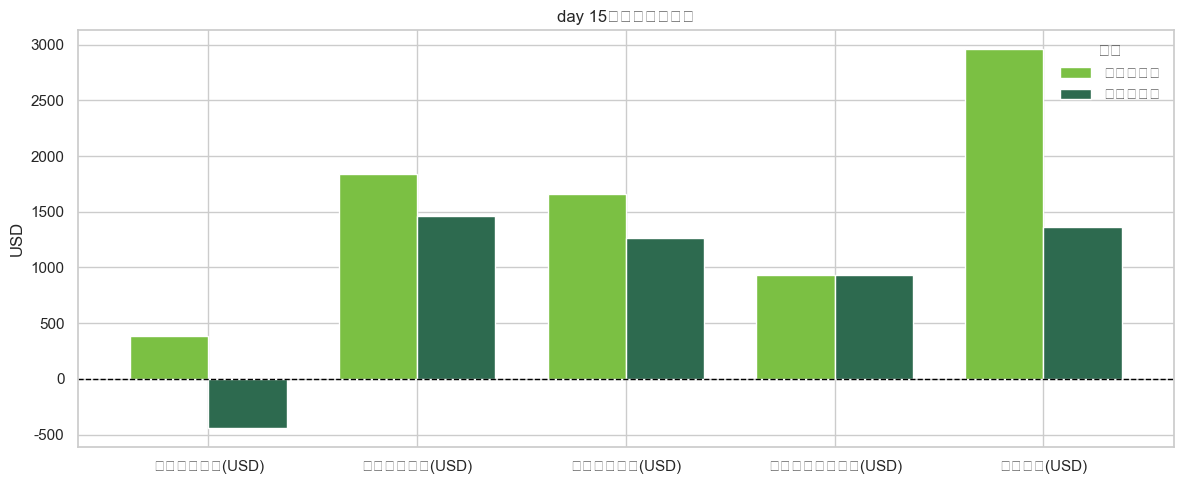

In [5]:
profit_components = summary_df.set_index("场景")[[
    "实际能量收益(USD)",
    "实际容量收益(USD)",
    "实际里程收益(USD)",
    "实际电池退化费用(USD)",
    "实际利润(USD)",
]]

ax = profit_components.T.plot(
    kind="bar",
    figsize=(12, 5),
    color=["#7BC043", "#2D6A4F"],
    width=0.75,
)
ax.set_title(f"day {DAY_PRICE}：收益构成对比")
ax.set_ylabel("USD")
ax.set_xlabel("")
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.legend(title="场景", frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
resource_with_pv = viz_utils.build_resource_df(sim_with_pv)
resource_without_pv = viz_utils.build_resource_df(sim_without_pv)

def aggregate_resource(resource_df: pd.DataFrame, value_col: str, label: str) -> pd.DataFrame:
    pivot = resource_df.pivot_table(index="slot", columns="resource_type", values=value_col, aggfunc="sum").fillna(0.0)
    pivot.columns.name = None
    pivot["场景"] = label
    return pivot.reset_index()

resource_bid_r_df = pd.concat([
    aggregate_resource(resource_with_pv, "bid_r_rev", "含光伏参与"),
    aggregate_resource(resource_without_pv, "bid_r_rev", "无光伏参与"),
], ignore_index=True)

display(resource_bid_r_df.groupby("场景")[["PV", "ES", "EV"]].sum().round(3))


,PV,ES,EV
场景,,,
含光伏参与,6.547,17.561,10.338
无光伏参与,0.000,17.561,10.338
